# Demo: flujo de delegación del orquestador multi-agente

Este notebook ejecuta el grafo **real** (LLM configurado en `.env`) con una consulta que obliga al supervisor a:

1. delegar en el **investigador** (búsqueda en la base de conocimiento de GenPet),
2. pasar los datos al **analista** (cálculos con herramientas),
3. validar con su rúbrica y cerrar con el **sintetizador**.

Al final se muestra la guarda contra el *supervisor infinito* con modelos falsos (sin API).

In [1]:
from dotenv import load_dotenv
from IPython.display import Image, Markdown, display

from config import DIAGRAMS_DIR, TRACES_DIR, get_llm_settings
from graph import create_orchestrator
from runner import run_query
from tracing import TraceRecorder

load_dotenv()
settings = get_llm_settings()
graph = create_orchestrator(settings)
print('LLM:', settings.label)

LLM: openrouter:openai/gpt-4.1-mini


## 1. Topología del grafo

Supervisor central; los especialistas siempre vuelven al supervisor (aristas sólidas) y el supervisor decide con aristas condicionales (punteadas).

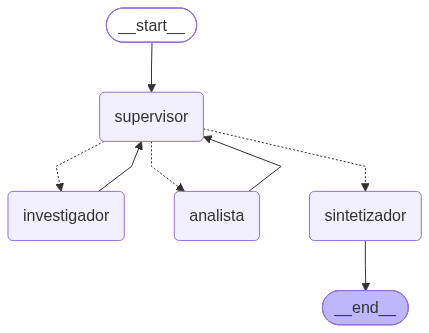

In [2]:
display(Image(filename=str(DIAGRAMS_DIR / 'graph.png')))

## 2. Consulta que requiere investigación + análisis + síntesis

In [3]:
from main import DEMO_QUESTION as consulta

recorder = TraceRecorder(echo=print, llm=settings.label)
final = await run_query(graph, consulta, recorder)
recorder.save(TRACES_DIR / 'notebook.json', TRACES_DIR / 'notebook.log')

Consulta: "Necesito un informe de desempeño de GenPet en 2026: ¿cuáles fueron los ingresos netos de cada trimestre (Q1 a Q3) y cuáles eran las metas del plan comercial? Calculá el crecimiento porcentual entre trimestres, el porcentaje de cumplimiento de cada meta y cuánto falta facturar en el Q4 para llegar al objetivo anual de ingresos. Si GenPet cumple exactamente la meta del Q4, ¿alcanza el objetivo anual?"



[1] supervisor -> investigador
    razonamiento: No hay datos aportados aún por el investigador sobre los ingresos netos trimestrales reales, las metas del plan comercial para cada trimestre y el objetivo anual de ingresos para 2026. Para responder la consulta completa, primero se necesitan estos datos específicos con sus fuentes y validación automática OK. Por lo tanto, el siguiente paso es pedir al investigador que busque estos datos.
    instrucción: Por favor, busca y aporta los siguientes datos para 2026: los ingresos netos reales de GenPet para cada trimestre Q1, Q2 y Q3; las metas del plan comercial para cada trimestre Q1 a Q4; y el objetivo anual de ingresos. Asegúrate de citar la fuente de cada dato y que la validación automática sea OK.



[2] investigador (intento 1) · 8 tool calls
    · buscar_base_conocimiento(consulta='ingresos netos 2026 Q1')
    · buscar_base_conocimiento(consulta='ingresos netos 2026 Q2')
    · buscar_base_conocimiento(consulta='ingresos netos 2026 Q3')
    · buscar_base_conocimiento(consulta='metas plan comercial 2026 Q1')
    · buscar_base_conocimiento(consulta='metas plan comercial 2026 Q2')
    · buscar_base_conocimiento(consulta='metas plan comercial 2026 Q3')
    · buscar_base_conocimiento(consulta='metas plan comercial 2026 Q4')
    · buscar_base_conocimiento(consulta='objetivo anual ingresos 2026')
    aporte: ## Datos encontrados - [REAL] Ingresos netos Q1 2026: $4.427.580 [fuente: historial_ventas_2026.md] - [REAL] Ingresos netos Q2 2026: $7.931.680 [fuente: historial_ventas_2026.md] - [REAL] Ingresos netos Q3 2026: $14.402.182 [fuente: historial_ventas_2026.md] - [META] Meta ingresos netos Q1 2026: $4.000.000 (Lanzamiento de la tienda web) [fuente: plan_comercial_2026.md] - [META] Meta


[3] supervisor -> analista
    razonamiento: El investigador aportó todos los datos solicitados: ingresos netos reales de Q1 a Q3, metas trimestrales de Q1 a Q4 y el objetivo anual, con fuentes citadas y validación automática OK. No se solicitaron ingresos reales de Q4, lo cual es correcto porque el trimestre no terminó. La consulta requiere cálculos de crecimiento porcentual entre trimestres, porcentaje de cumplimiento de metas, cuánto falta facturar en Q4 para alcanzar el objetivo anual y si cumpliendo la meta Q4 se alcanza el objetivo anual. Por lo tanto, el próximo paso es que el analista realice esos cálculos con los datos exactos p…
    instrucción: Con los siguientes datos, realiza los cálculos solicitados para 2026: Ingresos netos reales Q1: $4.427.580, Q2: $7.931.680, Q3: $14.402.182; Metas ingresos netos Q1: $4.000.000, Q2: $7.500.000, Q3: $12.000.000, Q4: $13.000.000; Objetivo anual ingresos netos: $36.000.000. Calcula: 1) crecimiento porcentual entre Q1-Q2 y Q2-Q3; 2) porc


[4] analista (intento 1) · 8 tool calls
    · variacion_porcentual(valor_inicial=4427580, valor_final=7931680)
    · variacion_porcentual(valor_inicial=7931680, valor_final=14402182)
    · cumplimiento_de_meta(valor_real=4427580, meta=4000000)
    · cumplimiento_de_meta(valor_real=7931680, meta=7500000)
    · cumplimiento_de_meta(valor_real=14402182, meta=12000000)
    · calcular(expresion='4427580 + 7931680 + 14402182')
    · calcular(expresion='36000000 - (4427580 + 7931680 + 14402182)')
    · calcular(expresion='4427580 + 7931680 + 14402182 + 13000000')
    aporte: ## Resultados - Crecimiento porcentual entre Q1 y Q2: 79.14% (cálculo: variacion_porcentual con valor_inicial=4427580 y valor_final=7931680) - Crecimiento porcentual entre Q2 y Q3: 81.58% (cálculo: variacion_porcentual con valor_inicial=7931680 y valor_final=14402182) - Porcentaje de cumplimiento de la meta en Q1: 110.69% (cálculo: cumplimiento_de_meta con valor_real=4427580 y meta=4000000) - Porcentaje de cumplimiento d


[5] supervisor -> sintetizador
    razonamiento: El investigador aportó todos los datos solicitados con fuentes y validación automática OK, incluyendo ingresos reales Q1-Q3, metas trimestrales Q1-Q4 y objetivo anual. El analista realizó correctamente todos los cálculos pedidos (crecimientos porcentuales, cumplimiento de metas, faltante para Q4 y evaluación del objetivo anual) con registro de herramientas y validación OK. No hay datos nuevos del investigador posteriores al último aporte del analista, y no se detectan inconsistencias ni errores en los cálculos. La consulta está cubierta en su totalidad con trazabilidad y cómputo verificado.



[6] sintetizador -> END

RESPUESTA FINAL
Los ingresos netos de GenPet en 2026 fueron:

- Q1: $4.427.580
- Q2: $7.931.680
- Q3: $14.402.182

Las metas del plan comercial para 2026 eran:

- Q1: $4.000.000
- Q2: $7.500.000
- Q3: $12.000.000
- Q4: $13.000.000
- Objetivo anual: superar $36.000.000

Crecimientos y cumplimiento:

- Crecimiento entre Q1 y Q2: 79,14%
- Crecimiento entre Q2 y Q3: 81,58%
- Cumplimiento de meta Q1: 110,69%
- Cumplimiento de meta Q2: 105,76%
- Cumplimiento de meta Q3: 120,02%

Para alcanzar el objetivo anual, falta facturar en Q4 $9.238.558. Si GenPet cumple exactamente la meta de Q4 ($13.000.000), el total anual será $39.761.442, superando el objetivo anual.

---

- Ingresos netos reales Q1 a Q3 provienen de historial_ventas_2026.md.
- Metas y objetivo anual provienen de plan_comercial_2026.md.
- Cálculos de crecimiento, cumplimiento, faltante y total anual realizados con los datos indicados.

Fuentes: historial_ventas_2026.md, plan_comercial_2026.md


## 3. Estado compartido: quién aportó qué

`decisions` registra cada decisión del supervisor y `contributions` cada aporte de un especialista (instrucción recibida + herramientas usadas).

In [4]:
print('Decisiones del supervisor:')
for d in final['decisions']:
    print(f"  paso {d['step']}: -> {d['next']}{' [GUARDA]' if d['forced'] else ''}")

print()
print('Aportes de los especialistas:')
for c in final['contributions']:
    validacion = 'OK' if not c['issues'] else c['issues']
    print(f"  {c['agent']} (intento {c['attempt']}) · validación: {validacion}")
    for tc in c['tool_calls']:
        print(f"      {tc['tool']}({tc['args']}) -> {tc['result'][:90]}")

print()
print('delegations =', final['delegations'], '| task_completed =', final['task_completed'])
print('mensajes en el historial compartido:', [getattr(m, 'name', None) or m.type for m in final['messages']])

Decisiones del supervisor:
  paso 1: -> investigador
  paso 2: -> analista
  paso 3: -> sintetizador

Aportes de los especialistas:
  investigador (intento 1) · validación: OK
      buscar_base_conocimiento({'consulta': 'ingresos netos 2026 Q1'}) -> {"consulta": "ingresos netos 2026 Q1", "resultados": [{"fuente": "plan_comercial_2026.md",
      buscar_base_conocimiento({'consulta': 'ingresos netos 2026 Q2'}) -> {"consulta": "ingresos netos 2026 Q2", "resultados": [{"fuente": "plan_comercial_2026.md",
      buscar_base_conocimiento({'consulta': 'ingresos netos 2026 Q3'}) -> {"consulta": "ingresos netos 2026 Q3", "resultados": [{"fuente": "plan_comercial_2026.md",
      buscar_base_conocimiento({'consulta': 'metas plan comercial 2026 Q1'}) -> {"consulta": "metas plan comercial 2026 Q1", "resultados": [{"fuente": "plan_comercial_202
      buscar_base_conocimiento({'consulta': 'metas plan comercial 2026 Q2'}) -> {"consulta": "metas plan comercial 2026 Q2", "resultados": [{"fuente": "plan_c

## 4. Respuesta final (sintetizador)

In [5]:
display(Markdown(final['final_answer']))

Los ingresos netos de GenPet en 2026 fueron:

- Q1: $4.427.580
- Q2: $7.931.680
- Q3: $14.402.182

Las metas del plan comercial para 2026 eran:

- Q1: $4.000.000
- Q2: $7.500.000
- Q3: $12.000.000
- Q4: $13.000.000
- Objetivo anual: superar $36.000.000

Crecimientos y cumplimiento:

- Crecimiento entre Q1 y Q2: 79,14%
- Crecimiento entre Q2 y Q3: 81,58%
- Cumplimiento de meta Q1: 110,69%
- Cumplimiento de meta Q2: 105,76%
- Cumplimiento de meta Q3: 120,02%

Para alcanzar el objetivo anual, falta facturar en Q4 $9.238.558. Si GenPet cumple exactamente la meta de Q4 ($13.000.000), el total anual será $39.761.442, superando el objetivo anual.

---

- Ingresos netos reales Q1 a Q3 provienen de historial_ventas_2026.md.
- Metas y objetivo anual provienen de plan_comercial_2026.md.
- Cálculos de crecimiento, cumplimiento, faltante y total anual realizados con los datos indicados.

Fuentes: historial_ventas_2026.md, plan_comercial_2026.md

## 5. Guarda contra el "supervisor infinito" (sin API)

Un supervisor guionado que **siempre** pide más investigación. Las guardas deterministas cortan el ciclo: al llegar al máximo de intentos del investigador se analizan los datos disponibles y luego se sintetiza. Se usan los dobles de prueba de `tests/conftest.py`.

In [6]:
from langchain_core.messages import AIMessage

from agents import make_analyst_node, make_research_node, make_supervisor_node, make_synthesizer_node
from agents.supervisor import SupervisorDecision
from graph import OrchestratorNodes, build_graph
from tests.conftest import fake_model, scripted_router
from tools import KnowledgeBase, build_math_tools, build_research_tools

router_obstinado = scripted_router(
    SupervisorDecision(reasoning='quiero más datos', next='investigador', instruction='buscá más')
    for _ in range(100))
grafo_loop = build_graph(OrchestratorNodes(
    supervisor=make_supervisor_node(router_obstinado),
    researcher=make_research_node(fake_model([AIMessage('dato')]), build_research_tools(KnowledgeBase())),
    analyst=make_analyst_node(fake_model([AIMessage('cálculo con lo disponible')]), build_math_tools()),
    synthesizer=make_synthesizer_node(fake_model([AIMessage('Respuesta parcial con lo disponible.')])),
))
_ = await run_query(grafo_loop, 'consulta imposible', TraceRecorder(echo=print))

Consulta: "consulta imposible"

[1] supervisor -> investigador
    razonamiento: quiero más datos
    instrucción: buscá más

[2] investigador (intento 1) · 0 tool calls
    aporte: dato

[3] supervisor -> investigador
    razonamiento: quiero más datos
    instrucción: buscá más

[4] investigador (intento 2) · 0 tool calls
    aporte: dato

[5] supervisor -> investigador
    razonamiento: quiero más datos
    instrucción: buscá más

[6] investigador (intento 3) · 0 tool calls
    aporte: dato

[7] supervisor -> analista [GUARDA]
    razonamiento: investigador ya intervino 3 veces (máximo 3): se analizan los datos disponibles.
    instrucción: Con los datos disponibles del investigador, calculá todo lo que pide la consulta del usuario. Lo que no se pueda calcular por falta de datos, listalo como faltante.

[8] analista (intento 1) · 0 tool calls
    aporte: cálculo con lo disponible

[9] supervisor -> sintetizador [GUARDA]
    razonamiento: investigador ya intervino 3 veces (máximo 3):